# Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [15]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.data.catalog as catalog
import src.utils.catalog_tests as catalog_tests
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
from src.utils.utils import set_seed
from src.utils.visualization import visualize_sequence

set_seed(0)
np.random.seed(0)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration

In [16]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'mixer_tpp_20260206-112901'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'

T_FORECAST = 13000
FORECAST_DURATION = 30
NUM_SAMPLES = 10000
SAMPLES_PER_BATCH = 2000
MAX_SAMPLE_LEN = 6000
PREDICT_B = True
USE_TORCH_COMPILE = True
MODEL_MM = 10.0

print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')

CHECKPOINT_PATH: /root/autodl-tmp/em_eqf/checkpoints/mixer_tpp_20260206-112901/best_model_1.pth


## 3) Load Trained Model

In [17]:
def load_model_and_args(checkpoint_path: Path, device: torch.device, use_compile: bool = True):
    check_point = torch.load(checkpoint_path, map_location=device, weights_only=False)
    args = load_args_from_checkpoint(None, check_point)

    model_builder = ModelBuilder.by_name(args.model.lower())()
    model = model_builder(args, device)
    model, _, _ = load_model_from_checkpoint(model, check_point)

    if use_compile and hasattr(torch, 'compile'):
        model = torch.compile(model)

    model.eval()
    return model, args


model, args = load_model_and_args(CHECKPOINT_PATH, DEVICE, use_compile=USE_TORCH_COMPILE)
if hasattr(model, 'M_m'):
    model.M_m = torch.tensor(MODEL_MM)

print(f'Model: {args.model} | Dataset: {args.dataset}')

Model: mixer_tpp | Dataset: SCEDC


## 4) Load Catalog and Build Forecast Interval

past events: 115605 | observed events (13000 to 13030): 90


/root/autodl-tmp/em_eqf/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

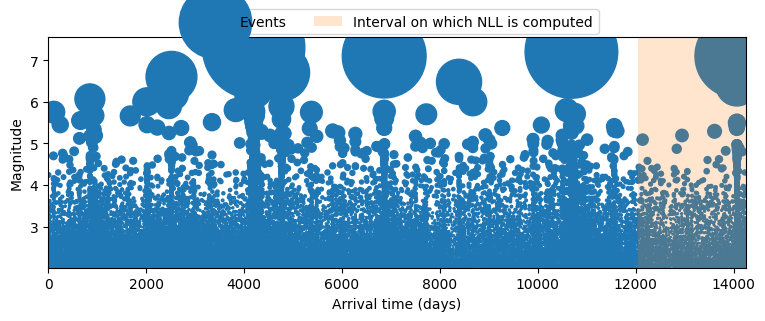

In [18]:
catalog_ds_class = catalog.Catalog.by_name(f'{args.dataset}-Standard')
catalog_ds = catalog_ds_class(root_dir=str(PROJECT_ROOT / 'data' / args.dataset / 'raw'))

train_seq = catalog_ds.train[0]
test_seq = catalog_ds.test[0]
past_seq = test_seq.get_subsequence(0, T_FORECAST)
observed_seq = test_seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION)
print(f'past events: {len(past_seq)} | observed events ({T_FORECAST} to {T_FORECAST + FORECAST_DURATION}): {len(observed_seq)}')

visualize_sequence(test_seq, show_nll=True)

In [19]:
catalog_ds.full_sequence

Sequence(
  inter_times: [125669],
  arrival_times: [125668],
  t_start: 0.0,
  t_end: 14243.999,
  t_nll_start: 0.0,
  mag: [125668]
)

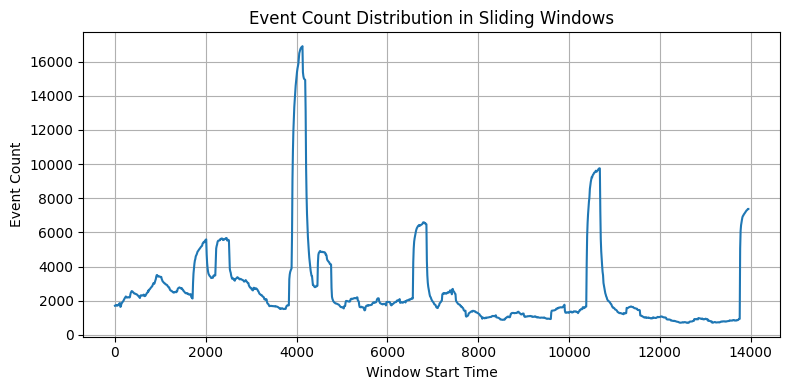

In [20]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()

plt.figure(figsize=(8, 4))
plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5) Generate Forecast Samples

In [21]:
def generate_forecasts(
    model,
    past_sequence,
    num_samples: int,
    samples_per_batch: int,
    duration: float,
    max_sample_len: int = 6000,
    predict_b: bool = True,
):
    if num_samples % samples_per_batch != 0:
        raise ValueError('num_samples must be divisible by samples_per_batch for deterministic batching.')

    model.eval()
    all_samples = []

    for _ in range(num_samples // samples_per_batch):
        batch_forecast = model.sample(
            batch_size=samples_per_batch,
            duration=duration,
            past_seq=past_sequence,
            return_sequences=True,
            max_sample_len=max_sample_len,
            predict_b=predict_b,
        )
        all_samples.extend(batch_forecast)

    return all_samples


if torch.cuda.is_available():
    model.to(DEVICE)
    past_seq = past_seq.to(DEVICE)

set_seed(0)
all_forecasts = generate_forecasts(
    model=model,
    past_sequence=past_seq,
    num_samples=NUM_SAMPLES,
    samples_per_batch=SAMPLES_PER_BATCH,
    duration=FORECAST_DURATION,
    max_sample_len=MAX_SAMPLE_LEN,
    predict_b=PREDICT_B,
)

print(f'Generated forecasts: {len(all_forecasts)}')

Generated forecasts: 10000


(<Figure size 1500x300 with 3 Axes>,
 (<Axes: title={'center': 'Observed Sequence and Example Forecast Trajectories'}, xlabel='Days since 1981-01-01', ylabel='Magnitude'>,
  <Axes: title={'center': 'Forecast counts'}, xlabel='Frequency', ylabel='Event count in window'>,
  <Axes: ylabel='Cumulative count'>))

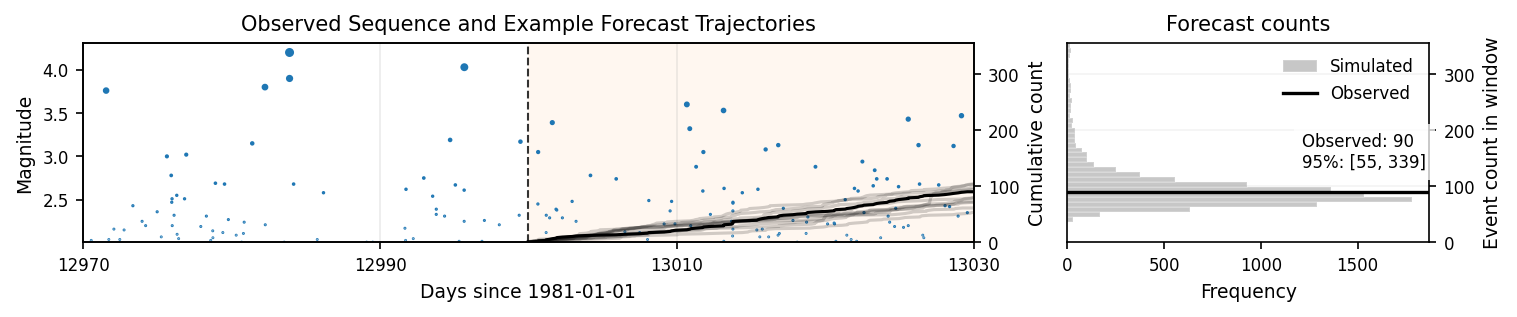

In [22]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(
    test_seq,
    all_forecasts,
    save_path=CHECKPOINT_DIR / 'all_forecasts.pdf',
    figsize=(10, 2),
    xlabel='Days since ' + date_str,
    offset=20,
)

## 6) N-Test (Event Count)

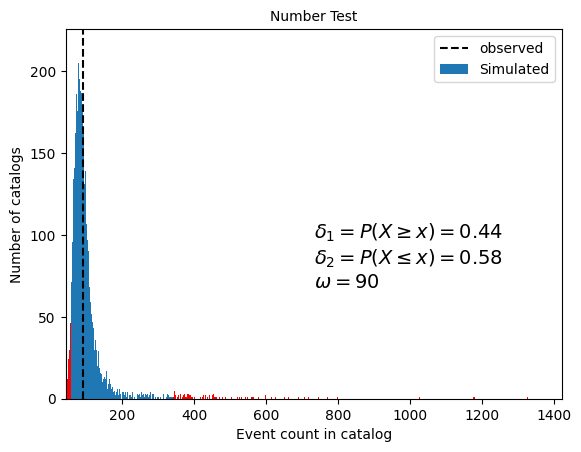

In [23]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
)

number_test_result.plot(plot_args={'figsize': (6.4, 4.8), 'tight_layout': False})
plt.savefig(CHECKPOINT_DIR / 'n_test.pdf')

## 7) M-Test (Magnitude Distribution)

In [24]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01,
}


def compute_b_mle(data, mmin, dmw=0.01):
    def _compute_from_mags(mags_t):
        sel = mags_t[mags_t >= mmin]
        n = int(sel.numel())
        if n == 0:
            raise ValueError('No magnitudes above or equal to mmin for b-value calculation.')
        mean_mag = float(sel.mean().item())
        b = 0.4342944819 / (mean_mag - (mmin - dmw / 2))
        b_se = b / (n ** 0.5)
        return b, b_se, n, mean_mag

    def _to_mags(x):
        if hasattr(x, 'mag'):
            x = x.mag
        if isinstance(x, torch.Tensor):
            return x.detach().to(device='cpu', dtype=torch.float32)
        if isinstance(x, np.ndarray):
            return torch.as_tensor(x, dtype=torch.float32, device='cpu')
        if isinstance(x, (list, tuple)) and len(x) > 0 and isinstance(x[0], (int, float)):
            return torch.as_tensor(x, dtype=torch.float32, device='cpu')
        raise TypeError(f'Unsupported input type: {type(x)}')

    if isinstance(data, (list, tuple)):
        per_catalog = []
        all_sel = []

        for cat in data:
            try:
                mags_t = _to_mags(cat)
                sel = mags_t[mags_t >= mmin]
                if sel.numel() == 0:
                    continue
                b_i, b_se_i, n_i, mean_i = _compute_from_mags(mags_t)
                per_catalog.append((float(b_i), float(b_se_i), int(n_i), float(mean_i)))
                all_sel.append(sel)
            except (TypeError, ValueError):
                continue

        if len(per_catalog) == 0:
            raise ValueError('No magnitudes at or above mmin in any catalog.')

        concat = torch.cat(all_sel)
        b_all, b_se_all, n_total, mean_all = _compute_from_mags(concat)
        return {
            'combined': (float(b_all), float(b_se_all), int(n_total), float(mean_all)),
            'per_catalog': per_catalog,
        }

    return _compute_from_mags(_to_mags(data))


b_mle, b_se, n, mean_mag = compute_b_mle(
    observed_seq,
    mmin=args.mag_completeness,
    dmw=config_dict.get('dmw', 0.01),
)
print(f'b (MLE): {b_mle:.3f} ± {b_se:.3f} (N={n}, mmin={args.mag_completeness}, mean={mean_mag:.3f})')

b (MLE): 0.911 ± 0.096 (N=90, mmin=2.0, mean=2.472)


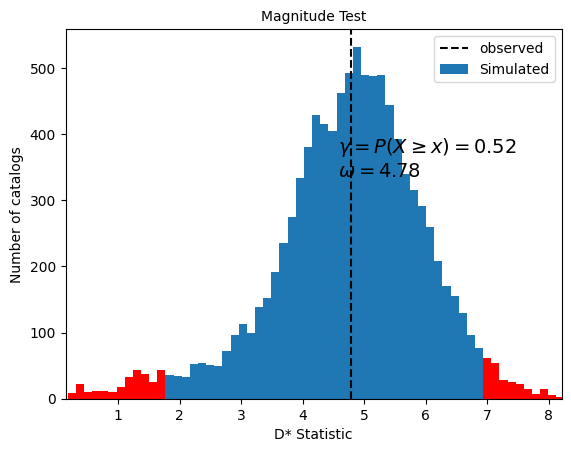

In [25]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
)

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
)
magnitude_test_result.plot(plot_args={'figsize': (6.4, 4.8), 'tight_layout': False, 'legend_loc': 'upper right'})
plt.savefig(CHECKPOINT_DIR / 'm_test.pdf')

In [26]:
CHECKPOINT_DIR

PosixPath('/root/autodl-tmp/em_eqf/checkpoints/mixer_tpp_20260206-112901')